# Plotting Each Column of simout.csv

This notebook loads the CSV file located at `./data/simout.csv`, inspects and cleans the data, and then plots each column both as subplots and as individual figures. Optionally, an interactive selector is provided to toggle columns for plotting.

## 1. Import Required Libraries
We will use pandas for data handling, matplotlib for plotting, and optionally seaborn for improved plot aesthetics. IPython.display is used for displaying images inline.

In [96]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Image
import os

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context('notebook')

# Ensure plots directory exists
os.makedirs('./plots', exist_ok=True)

## 2. Load the default CSV files
Compare default Matlab vs CPP results for a step disturbance in angular momentum

In [97]:
# Read the CSV file
#csv_path = '../ADCS/CPP/data/simout.csv'
dfM = pd.read_csv('./data/matlabDefault.csv')
dfC = pd.read_csv('./data/cppDefault.csv')
#display(dfM.head())
#display(dfC.head())

## 3. Handle missing data
There should be no missing rows, but attempt to convert all columns to numeric types, coercing errors to NaN. Drop any NaN rows.

In [98]:
# Attempt to coerce all columns to numeric, non-numeric columns will become NaN
df_numeric = dfM.apply(pd.to_numeric, errors='coerce')

# Show columns with NaNs after coercion
nan_cols = df_numeric.columns[df_numeric.isna().any()].tolist()
print('Columns with NaNs after coercion:', nan_cols)

# Drop rows with NaNs (if few)
df_mat = df_numeric.dropna()
print('Shape after dropna:', df_mat.shape)

display(df_mat.head())

df_numeric = dfC.apply(pd.to_numeric, errors='coerce')

# Show columns with NaNs after coercion
nan_cols = df_numeric.columns[df_numeric.isna().any()].tolist()
print('Columns with NaNs after coercion:', nan_cols)

# Drop rows with NaNs (if few)
df_cpp = df_numeric.dropna()
print('Shape after dropna:', df_cpp.shape)

display(df_cpp.head())

Columns with NaNs after coercion: []
Shape after dropna: (10001, 5)


,time,theta,q,e,H
0,0.000,0.000000,1.000000,-0.732051,1
1,0.001,0.000999,0.998269,-0.731783,1
2,0.002,0.001997,0.996540,-0.731514,1
3,0.003,0.002992,0.994813,-0.731246,1
4,0.004,0.003986,0.993088,-0.730977,1


Columns with NaNs after coercion: []
Shape after dropna: (10001, 7)


,Time,u[0],d[0],x[0],x[1],x[2],y[0]
0,0.000,-0.732051,0,0.000999,0.998269,1,0.732051
1,0.001,-0.731783,0,0.001997,0.996540,1,0.731783
2,0.002,-0.731514,0,0.002992,0.994812,1,0.731514
3,0.003,-0.731245,0,0.003986,0.993087,1,0.731245
4,0.004,-0.730976,0,0.004978,0.991364,1,0.730976


## 4. Overlay Matlab and CPP results

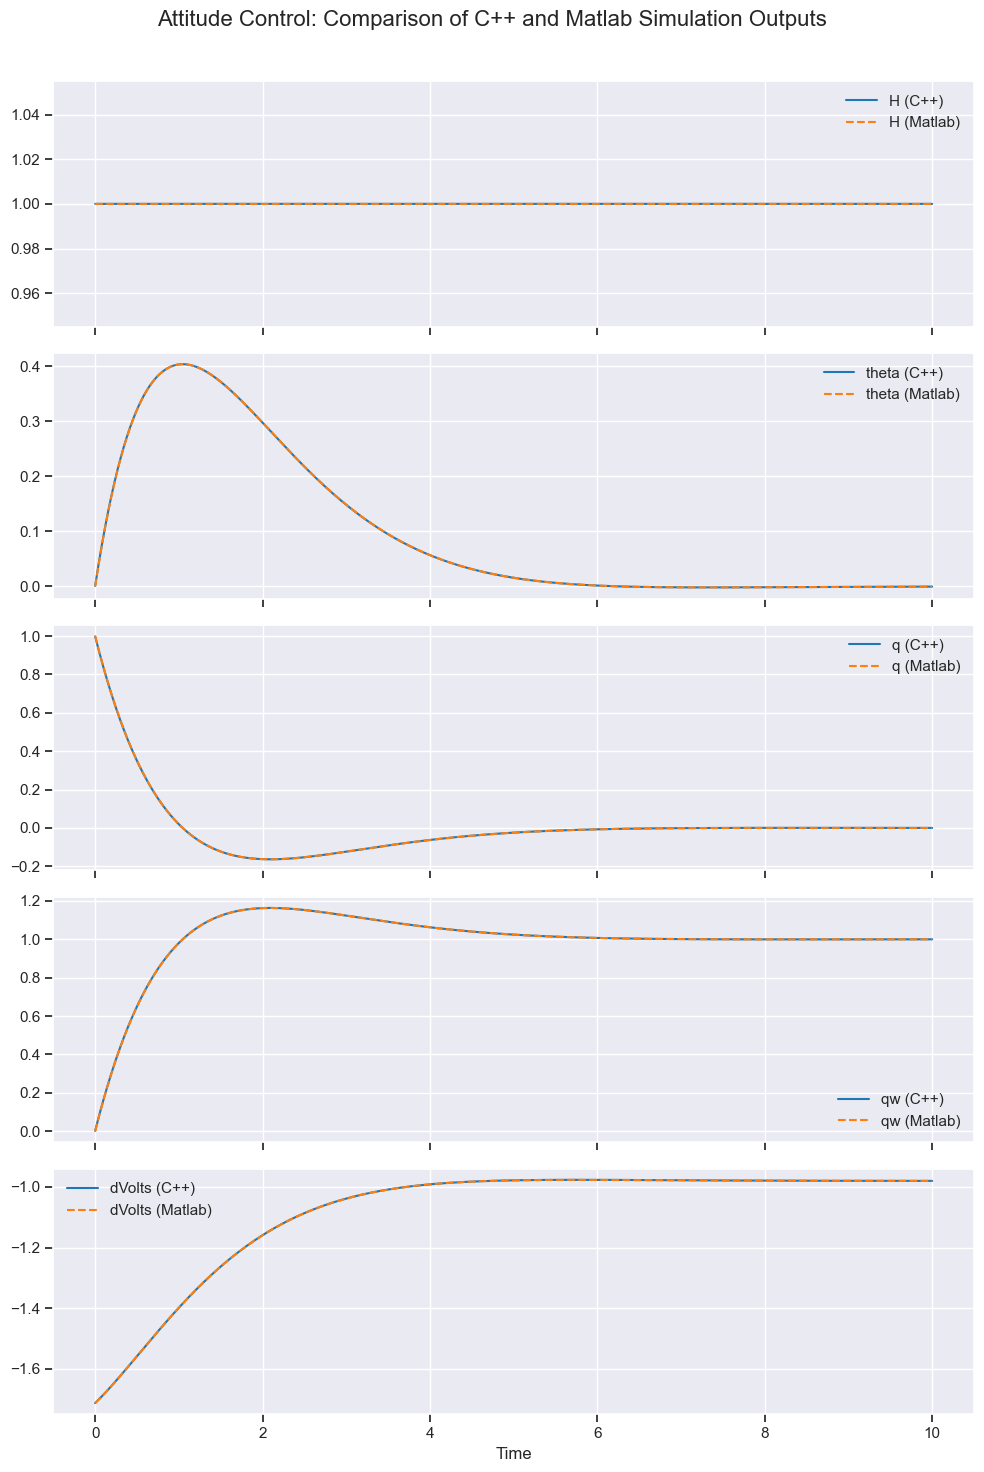

In [99]:
# J*qw/Iy
df_cpp['qw'] = df_cpp['x[2]'] - df_cpp['x[1]']
df_mat['qw'] = df_mat['H'] - df_mat['q']
df_cpp['dVolts'] = -1/(1 + 0.02) - df_cpp['y[0]'];
df_mat['dVolts'] = -1/(1 + 0.02) + df_mat['e']

num_cols = 5
fig, axes = plt.subplots(num_cols, 1, figsize=(10, 3*num_cols), sharex=True)
timeC = df_cpp['Time']
timeM = df_mat['time']

col = 'x[2]'
axes[0].plot(timeC, df_cpp[col], label='H (C++)')
axes[0].plot(timeM, df_mat['H'], label='H (Matlab)', linestyle='--')
axes[0].legend(loc='best')
axes[0].grid(True)

col = 'x[0]'
axes[1].plot(timeC, df_cpp[col], label='theta (C++)')
axes[1].plot(timeM, df_mat['theta'], label='theta (Matlab)', linestyle='--')
axes[1].legend(loc='best')
axes[1].grid(True)

col = 'x[1]'
axes[2].plot(timeC, df_cpp[col], label='q (C++)')
axes[2].plot(timeM, df_mat['q'], label='q (Matlab)', linestyle='--')
axes[2].legend(loc='best')
axes[2].grid(True)

col = 'qw'
axes[3].plot(timeC, df_cpp['qw'], label='qw (C++)')
axes[3].plot(timeM, df_mat['qw'], label='qw (Matlab)', linestyle='--')
axes[3].legend(loc='best')
axes[3].grid(True)


col = 'dVolts'
axes[4].plot(timeC, df_cpp[col], label='dVolts (C++)')
axes[4].plot(timeM, df_mat['dVolts'], label='dVolts (Matlab)', linestyle='--')
axes[4].legend(loc='best')
axes[4].grid(True)
axes[-1].set_xlabel('Time')
fig.suptitle('Attitude Control: Comparison of C++ and Matlab Simulation Outputs', fontsize=16)
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## 5. CPP model under active disturbance
A more realistic scenario to model jitter and gimbal motion

Columns with NaNs after coercion: []
Shape after dropna: (10001, 7)


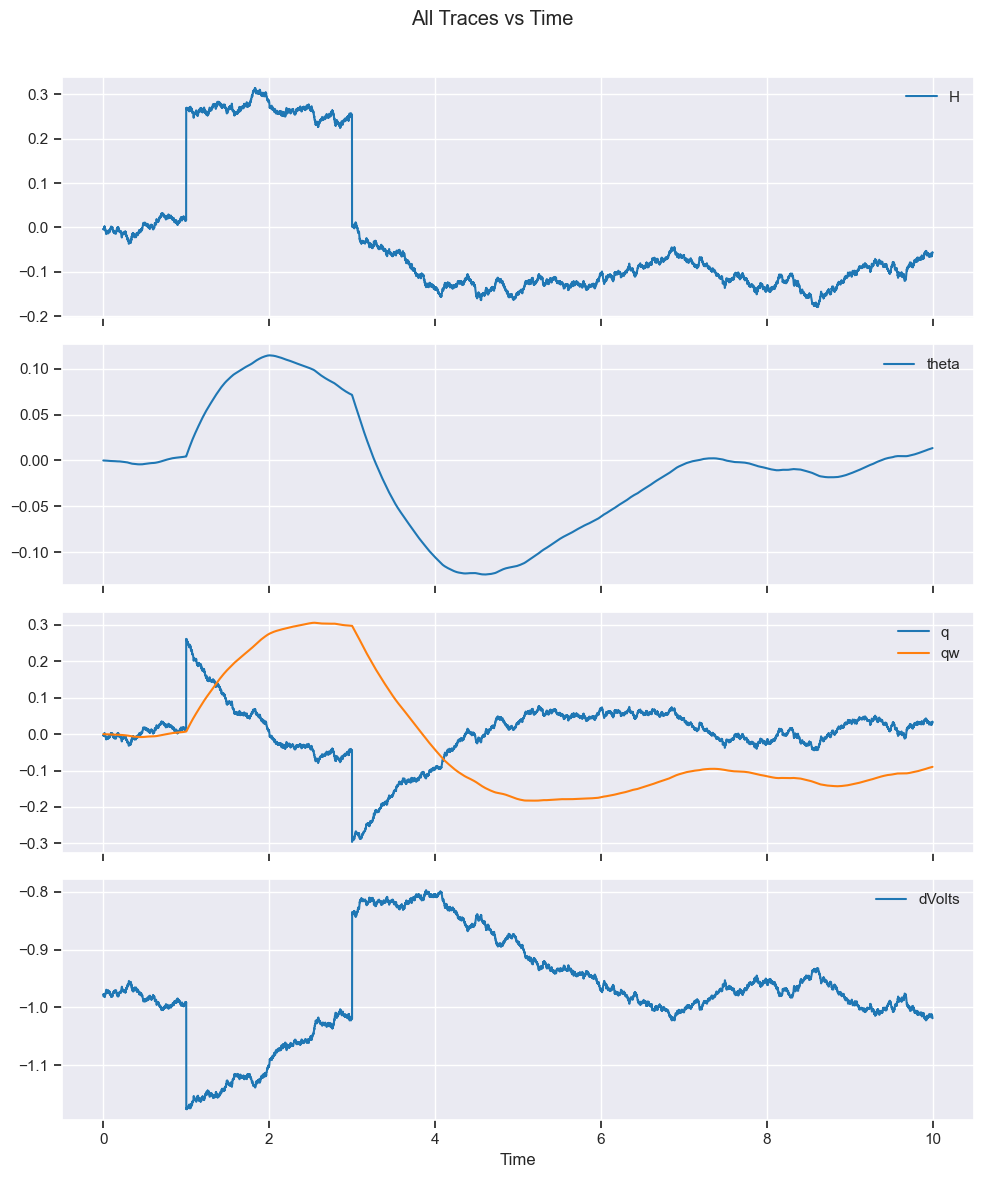

In [103]:
dfC = pd.read_csv('../ADCS/CPP/data/simout.csv')
df_numeric = dfC.apply(pd.to_numeric, errors='coerce')
nan_cols = df_numeric.columns[df_numeric.isna().any()].tolist()
print('Columns with NaNs after coercion:', nan_cols)
df_cpp = df_numeric.dropna()
print('Shape after dropna:', df_cpp.shape)
#display(df_cpp.head())

df_cpp['qw'] = df_cpp['x[2]'] - df_cpp['x[1]']
df_cpp['dVolts'] = -1/(1 + 0.02) - df_cpp['y[0]'];

colNames = {}
colNames['y[0]'] = 'dVolts'
colNames['x[0]'] = 'theta'
colNames['x[1]'] = 'q'
colNames['x[2]'] = 'H'

num_cols = 4
fig, axes = plt.subplots(num_cols, 1, figsize=(10, 3*num_cols), sharex=True)
time = df_cpp['Time']

col = 'x[2]'
axes[0].plot(time, df_cpp[col], label=colNames.get(col, col))
axes[0].legend(loc='best')
axes[0].grid(True)

col = 'x[0]'
axes[1].plot(time, df_cpp[col], label=colNames.get(col, col))
axes[1].legend(loc='best')
axes[1].grid(True)

col = 'x[1]'
axes[2].plot(time, df_cpp[col], label=colNames.get(col, col))
axes[2].plot(time, df_cpp['qw'], label='qw')
axes[2].legend(loc='best')
axes[2].grid(True)


col = 'dVolts'
axes[3].plot(time, df_cpp[col], label=col)
axes[3].legend(loc='best')
axes[3].grid(True)
axes[-1].set_xlabel('Time')
fig.suptitle('All Traces vs Time')
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()


## 6. Plot Each Column Separately and Save PNGs
For each column, we will create a separate figure, save it as a PNG in the `./plots/` directory, and display a thumbnail in the notebook.

## 7. Interactive Column Selector (Optional)
Use the widget below to interactively select columns to plot. This requires `ipywidgets` to be installed.